In [1]:
from scipy.stats import randint, uniform
import sys
from pathlib import Path

# Go up one level to project root
project_root = Path.cwd().parent.parent
sys.path.insert(0, str(project_root))

from src.utils.tune_hyperparameters import ModelTuner, PipelineTuner
from src.utils.load_data import get_split_from_file
filename = r"../../data/processed/no_cat_unknown.csv"


# model
from sklearn.ensemble import RandomForestClassifier


from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

e:\dev\workspace\Apziva\Project2\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
random_state = 0


Fitting 5 folds for each of 100 candidates, totalling 500 fits
[CV 1/5; 1/100] START classifier__bootstrap=True, classifier__max_depth=14, classifier__n_estimators=67
[CV 1/5; 1/100] END classifier__bootstrap=True, classifier__max_depth=14, classifier__n_estimators=67;, score=(train=0.990, test=0.944) total time=   0.9s
[CV 2/5; 1/100] START classifier__bootstrap=True, classifier__max_depth=14, classifier__n_estimators=67
[CV 2/5; 1/100] END classifier__bootstrap=True, classifier__max_depth=14, classifier__n_estimators=67;, score=(train=0.991, test=0.934) total time=   0.9s
[CV 3/5; 1/100] START classifier__bootstrap=True, classifier__max_depth=14, classifier__n_estimators=67
[CV 3/5; 1/100] END classifier__bootstrap=True, classifier__max_depth=14, classifier__n_estimators=67;, score=(train=0.991, test=0.931) total time=   0.9s
[CV 4/5; 1/100] START classifier__bootstrap=True, classifier__max_depth=14, classifier__n_estimators=67
[CV 4/5; 1/100] END classifier__bootstrap=True, classifi

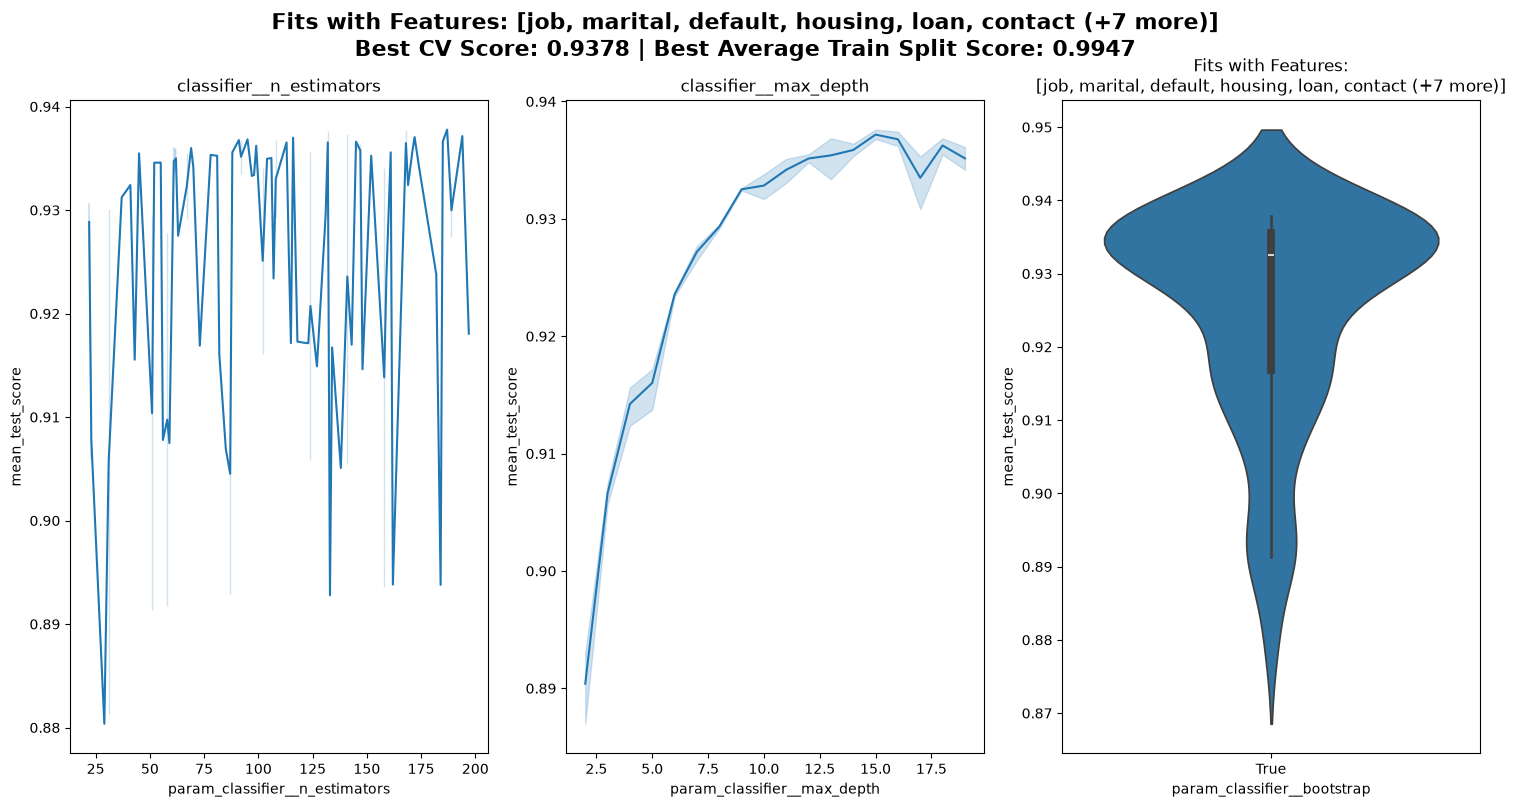



Feature Permutation Importance
______________________
duration: 0.297 +/- 0.006
month: 0.091 +/- 0.008
day: 0.024 +/- 0.003
housing: 0.010 +/- 0.001
balance: 0.003 +/- 0.001
age: 0.003 +/- 0.001
campaign: 0.002 +/- 0.001
loan: 0.001 +/- 0.001
contact: 0.000 +/- 0.000
marital: 0.000 +/- 0.001
education: 0.000 +/- 0.000
default: 0.000 +/- 0.000
job: -0.000 +/- 0.001

______________________



classifier:  RandomForestClassifier(max_depth=15, n_estimators=141, random_state=0) 





e:\dev\workspace\Apziva\Project2\src\utils\tune_hyperparameters.py:433: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values.values[:, :, i], X_test_transformed_df, show=False)


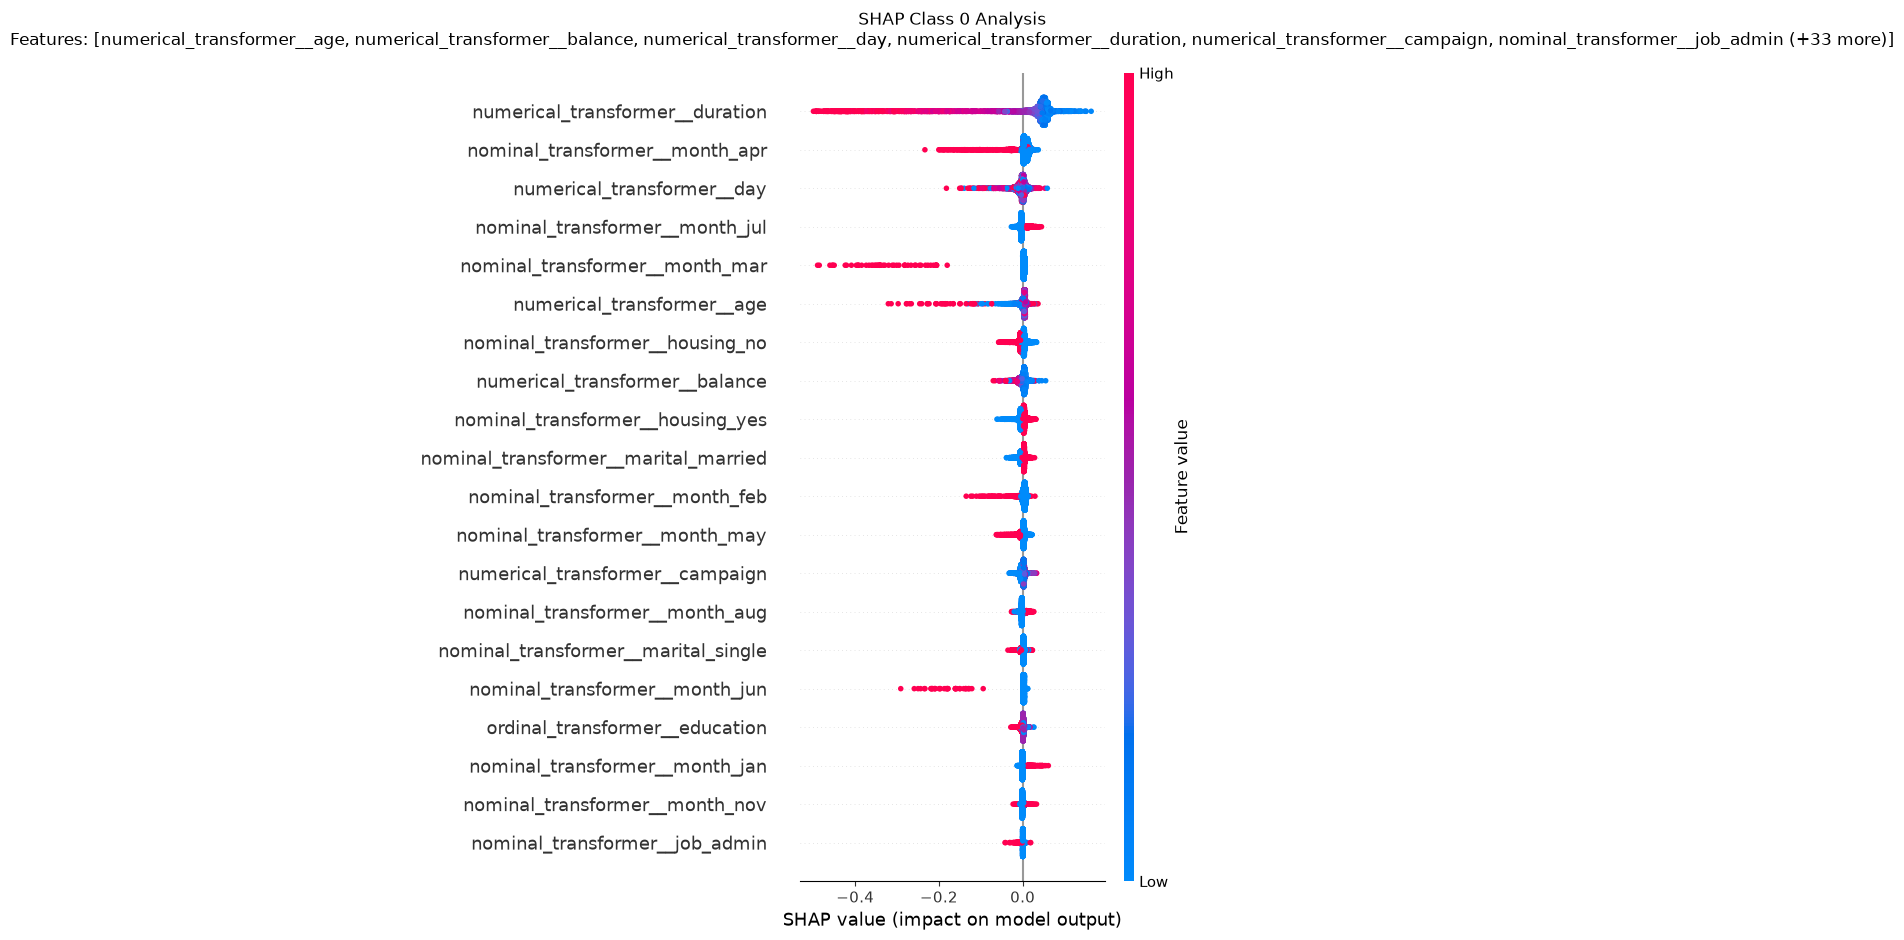

e:\dev\workspace\Apziva\Project2\src\utils\tune_hyperparameters.py:433: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values.values[:, :, i], X_test_transformed_df, show=False)


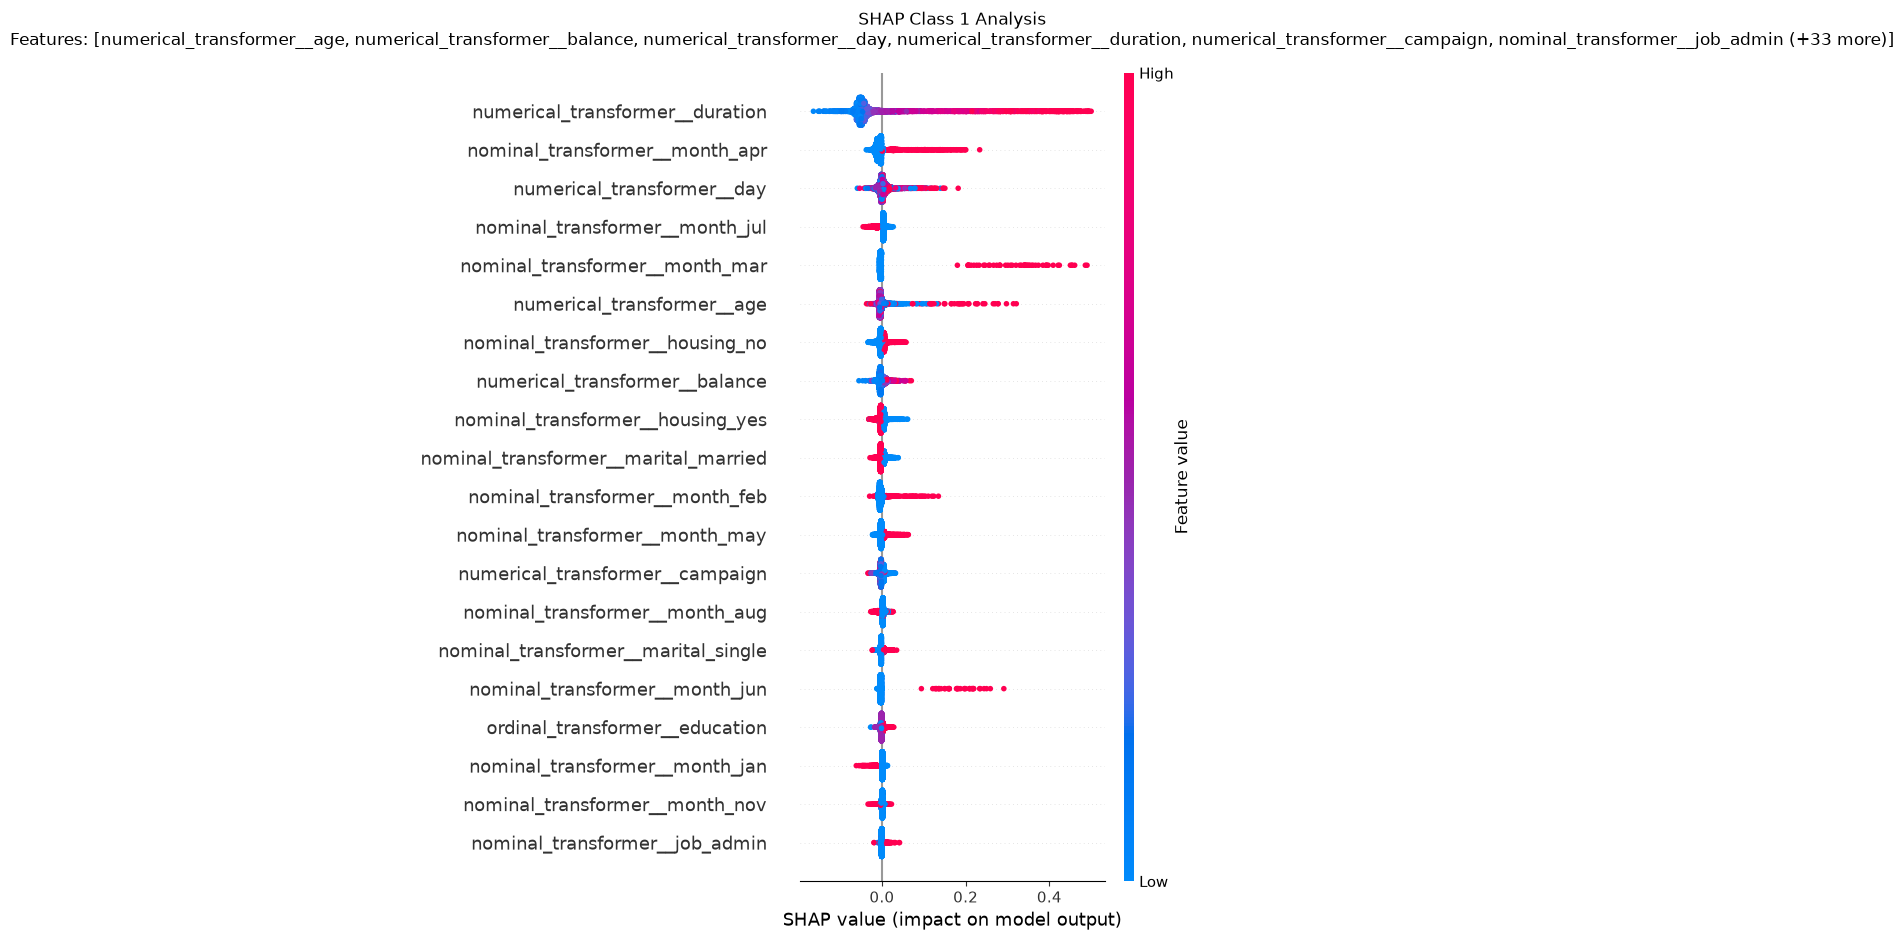

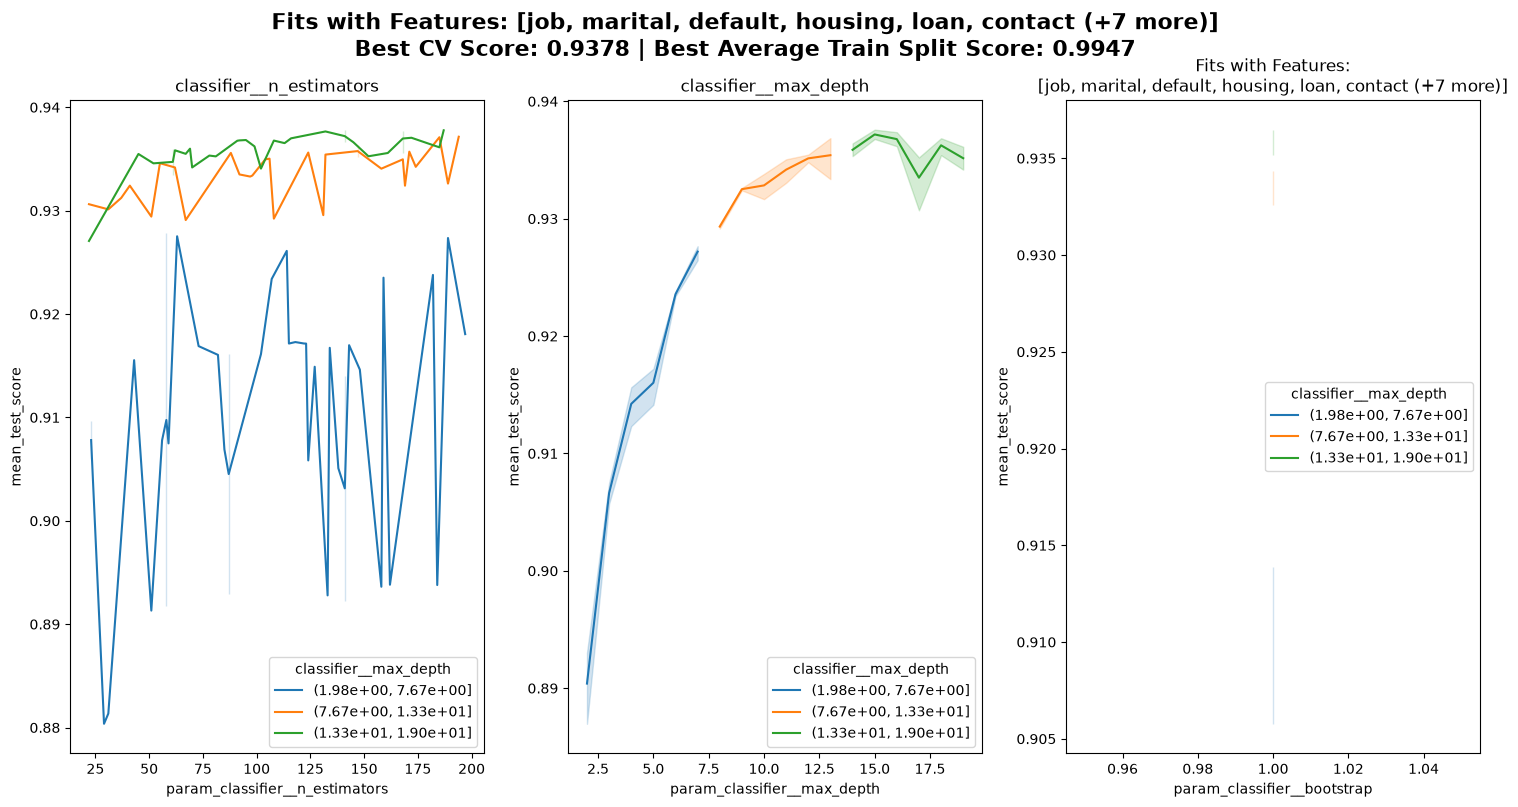

In [3]:
# Define your features
nominal_features = ['job', 'marital',  'default', 'housing', 'loan', 'contact', 'month',]

ordinal_features = ['education',]
education_order = ["primary", "secondary", "tertiary"]

numerical_features = ['age', 'balance','day', 'duration', 'campaign',]

all_features = nominal_features + ordinal_features + numerical_features



# 2. Create the transformers
numerical_transformer = Pipeline(
    steps=[
        ("Numerical", StandardScaler()),  
    ]
)
nominal_transformer = Pipeline(
    steps=[
        ("NominalEncoder", OneHotEncoder()),  
    ]
)
ordinal_transformer = Pipeline(
    steps=[
        ("OrdinalEncoder", OrdinalEncoder(categories=[education_order])), 
        ("OrdinalScaler", StandardScaler()),  
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numerical_transformer",
            numerical_transformer,
            numerical_features,
        ),
        (
            "nominal_transformer",
            nominal_transformer,
            nominal_features,
        ),
        (
            "ordinal_transformer",
            ordinal_transformer,
            ordinal_features,
        ),
    ],
    remainder="passthrough",  # Keeps any other columns untouched
)

# 4. Final Pipeline structure containing the PCA preprocessor and your classifier
pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(random_state=random_state)),
    ]
)

parameter_grid = {
    "classifier__n_estimators": randint(20, 200),
    "classifier__max_depth": randint(2,20),
    # "classifier__min_samples_split": randint(2, 21),
    # "classifier__min_samples_leaf": randint(1, 21),
    # "classifier__max_features": ["sqrt", "log2", None],
    # "classifier__min_weight_fraction_leaf": uniform(0.0, 0.5),
    "classifier__bootstrap": [True],
}


split = get_split_from_file(filename = filename, predictor='y', random_state = random_state)
t = PipelineTuner(pipeline, split=split, featureNames=all_features, random_state = random_state)
search = t.tune_model(hyperParameterGrid=parameter_grid, n_iter = 100, scoring = 'roc_auc')
t.feature_permutation(search.best_params_, scoring = 'roc_auc')
t.shap_analysis(search.best_params_)
t.display_parameter_fits(search, parameter_grid, groupby="classifier__max_depth")

In [4]:
scores = t.predict_test_split(t.last_search.best_params_, scoring = ["roc_auc","accuracy"])
print(scores)

{'roc_auc': 0.9324020467019852, 'accuracy': 0.9241300627495722}


In [5]:
random_state += 1

Fitting 5 folds for each of 200 candidates, totalling 1000 fits
[CV 1/5; 1/200] START classifier__bootstrap=True, classifier__max_depth=7, classifier__min_samples_leaf=13, classifier__min_samples_split=73, classifier__n_estimators=157
[CV 1/5; 1/200] END classifier__bootstrap=True, classifier__max_depth=7, classifier__min_samples_leaf=13, classifier__min_samples_split=73, classifier__n_estimators=157;, score=(train=0.934, test=0.935) total time=   1.2s
[CV 2/5; 1/200] START classifier__bootstrap=True, classifier__max_depth=7, classifier__min_samples_leaf=13, classifier__min_samples_split=73, classifier__n_estimators=157
[CV 2/5; 1/200] END classifier__bootstrap=True, classifier__max_depth=7, classifier__min_samples_leaf=13, classifier__min_samples_split=73, classifier__n_estimators=157;, score=(train=0.936, test=0.920) total time=   1.1s
[CV 3/5; 1/200] START classifier__bootstrap=True, classifier__max_depth=7, classifier__min_samples_leaf=13, classifier__min_samples_split=73, classifi

e:\dev\workspace\Apziva\Project2\.venv\Lib\site-packages\sklearn\model_selection\_validation.py:489: FitFailedWarning: 
10 fits failed out of a total of 1000.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
10 fits failed with the following error:
Traceback (most recent call last):
  File "e:\dev\workspace\Apziva\Project2\.venv\Lib\site-packages\sklearn\model_selection\_validation.py", line 851, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "e:\dev\workspace\Apziva\Project2\.venv\Lib\site-packages\sklearn\base.py", line 1403, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "e:\dev\workspace\Apziva\Project2\.venv\Lib\site-packages\sklearn\pi

|I|Randomized Search Best Score:  0.9341872911671982
|I|Randomized Search Best Estimator:  Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('numerical_transformer',
                                                  Pipeline(steps=[('Numerical',
                                                                   StandardScaler())]),
                                                  ['age', 'balance', 'day',
                                                   'duration', 'campaign']),
                                                 ('nominal_transformer',
                                                  Pipeline(steps=[('NominalEncoder',
                                                                   OneHotEncoder())]),
                                                  ['job', 'marital', 'default',
                                                   'housing', 'loan', 'contact',
              

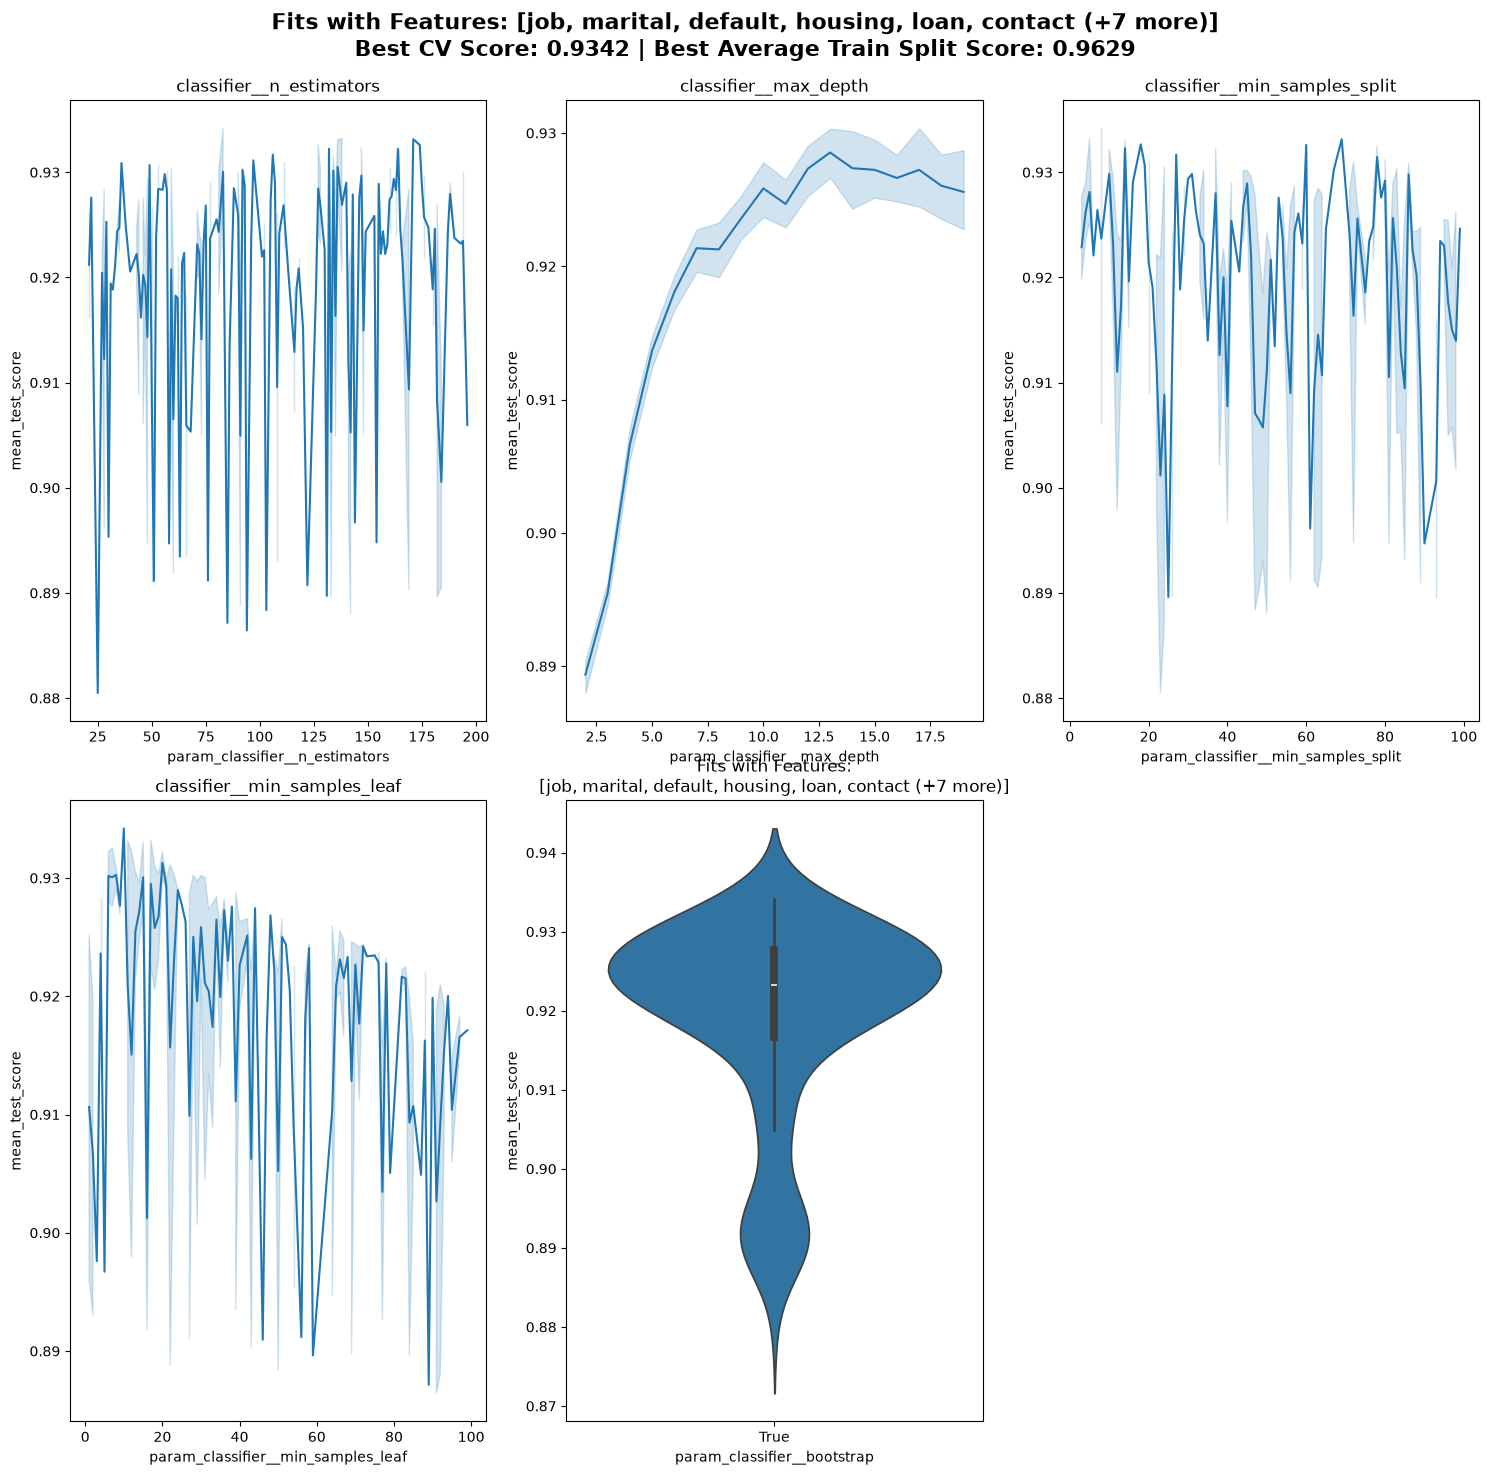



Feature Permutation Importance
______________________
duration: 0.300 +/- 0.006
month: 0.083 +/- 0.006
day: 0.019 +/- 0.002
housing: 0.008 +/- 0.001
campaign: 0.002 +/- 0.001
age: 0.002 +/- 0.001
contact: 0.001 +/- 0.000
balance: 0.001 +/- 0.001
loan: 0.000 +/- 0.000
default: 0.000 +/- 0.000
marital: -0.000 +/- 0.001
education: -0.001 +/- 0.001
job: -0.001 +/- 0.000

______________________



classifier:  RandomForestClassifier(max_depth=15, min_samples_leaf=10, min_samples_split=8,
                       n_estimators=83, random_state=1) 





e:\dev\workspace\Apziva\Project2\src\utils\tune_hyperparameters.py:433: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values.values[:, :, i], X_test_transformed_df, show=False)


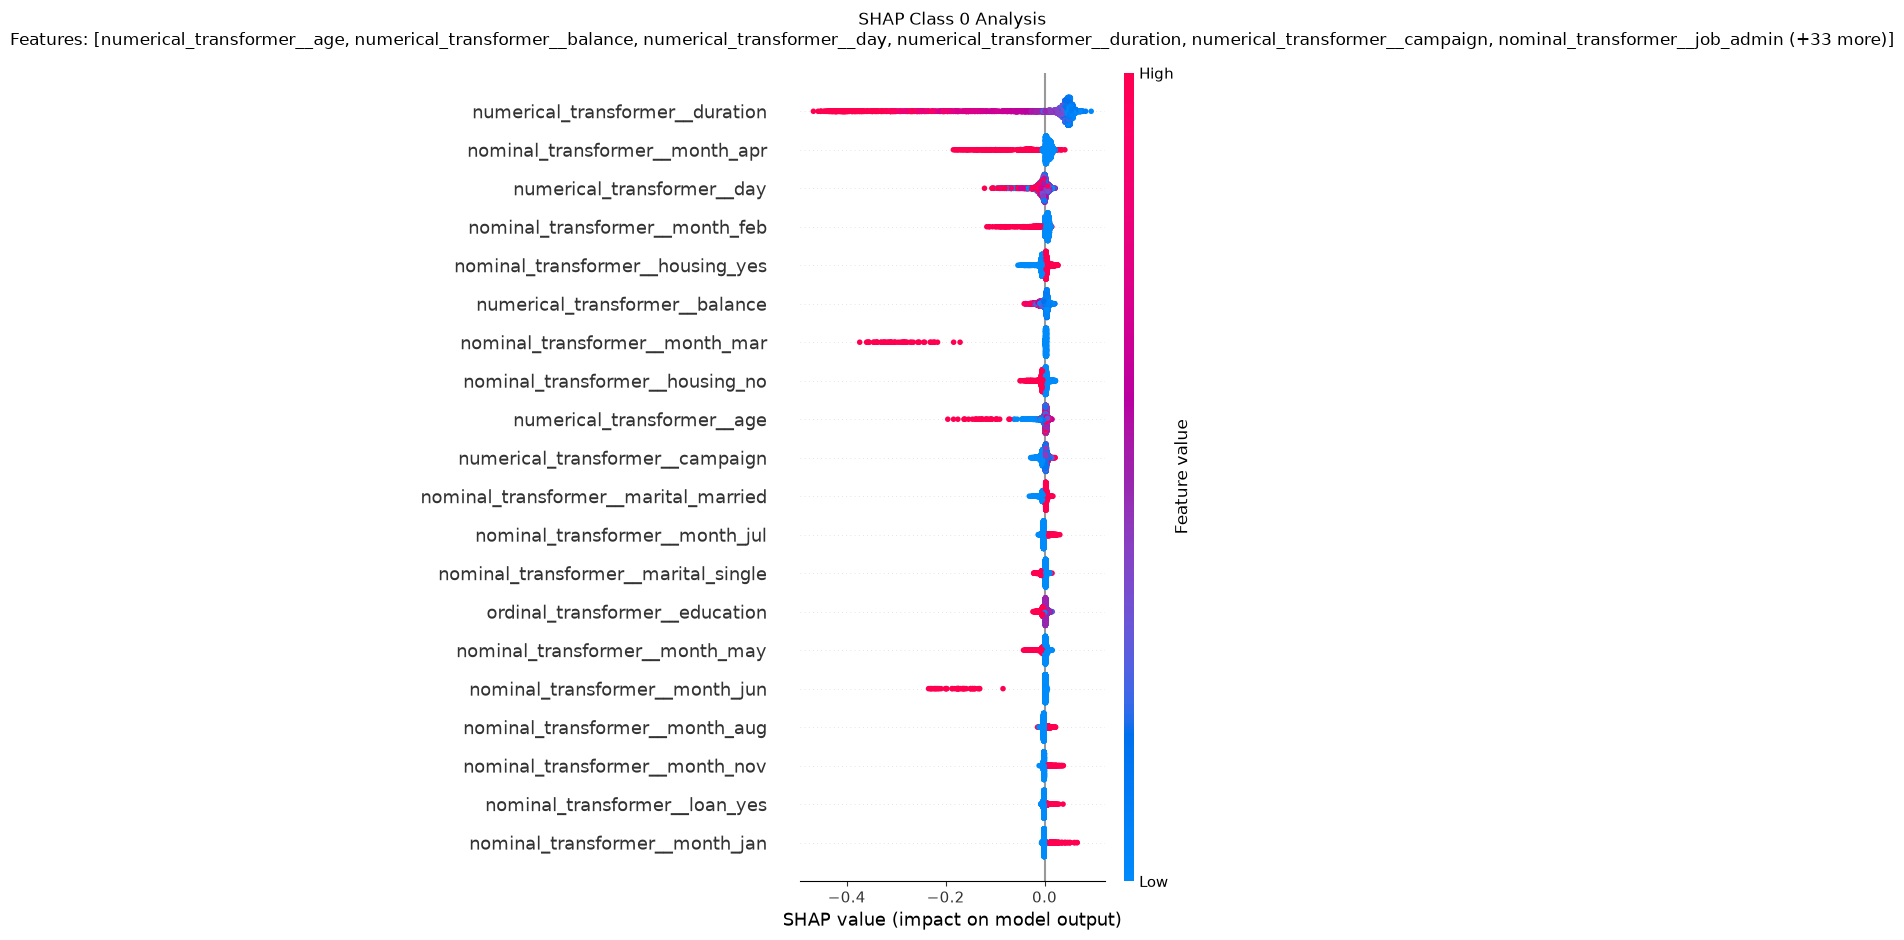

e:\dev\workspace\Apziva\Project2\src\utils\tune_hyperparameters.py:433: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values.values[:, :, i], X_test_transformed_df, show=False)


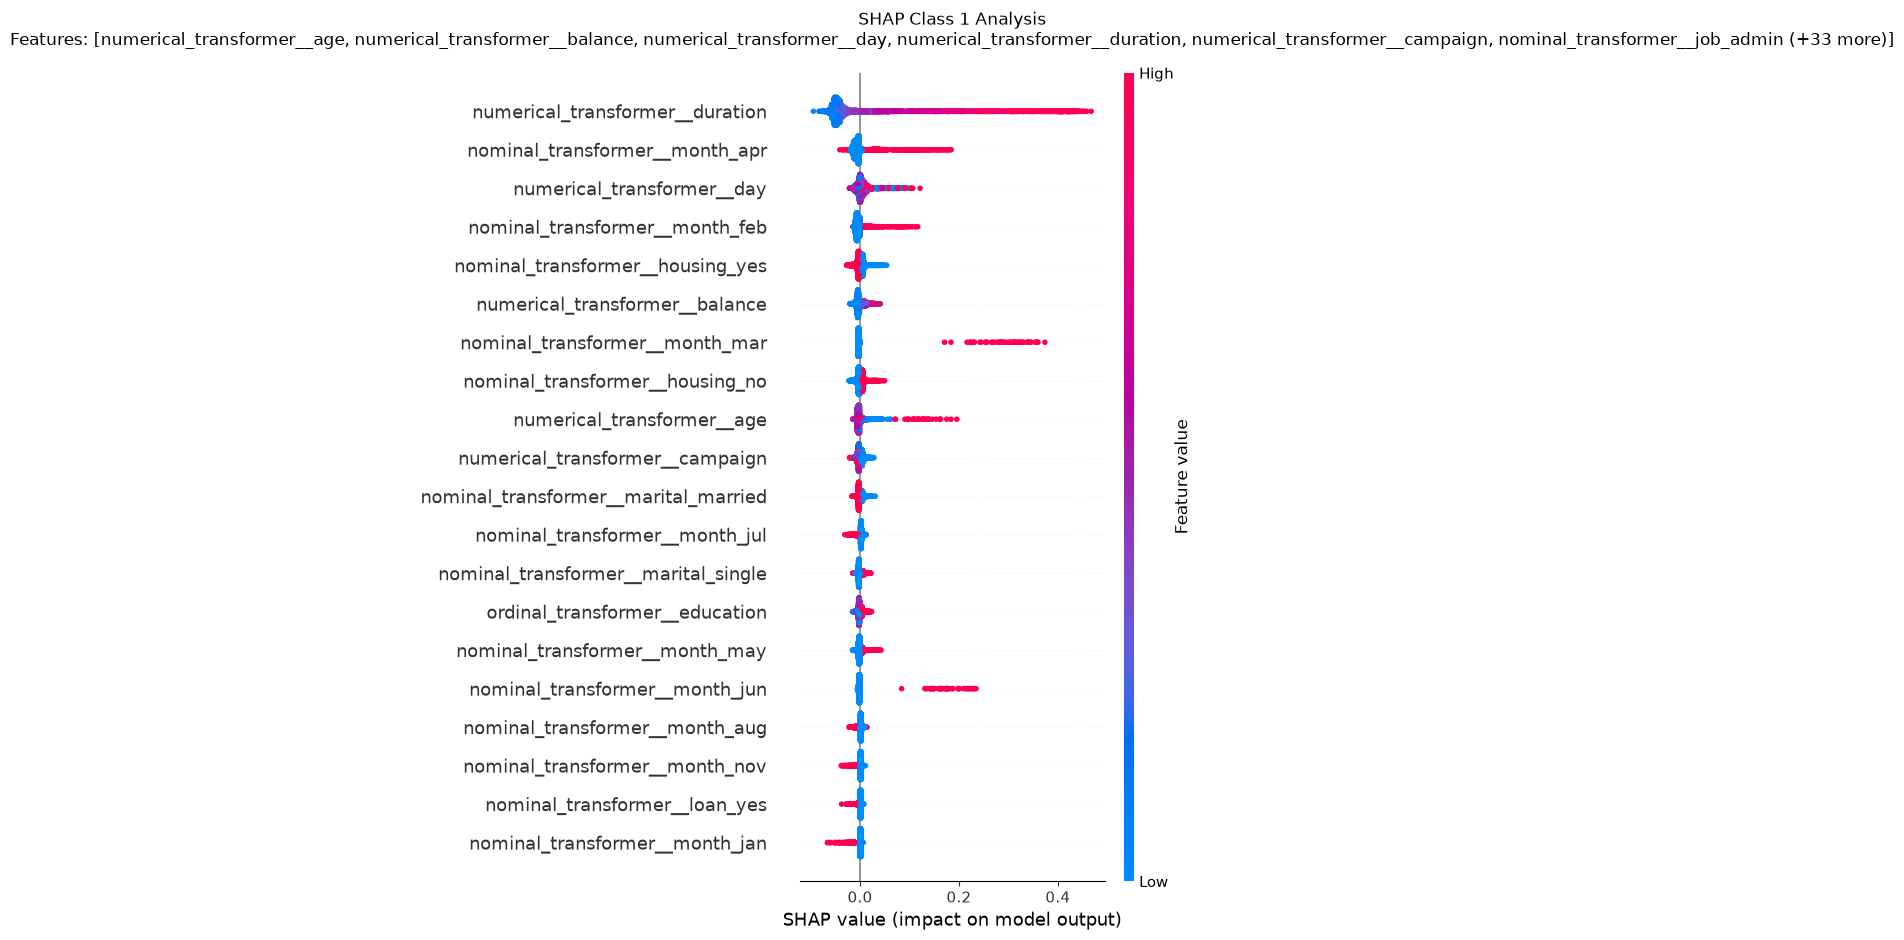

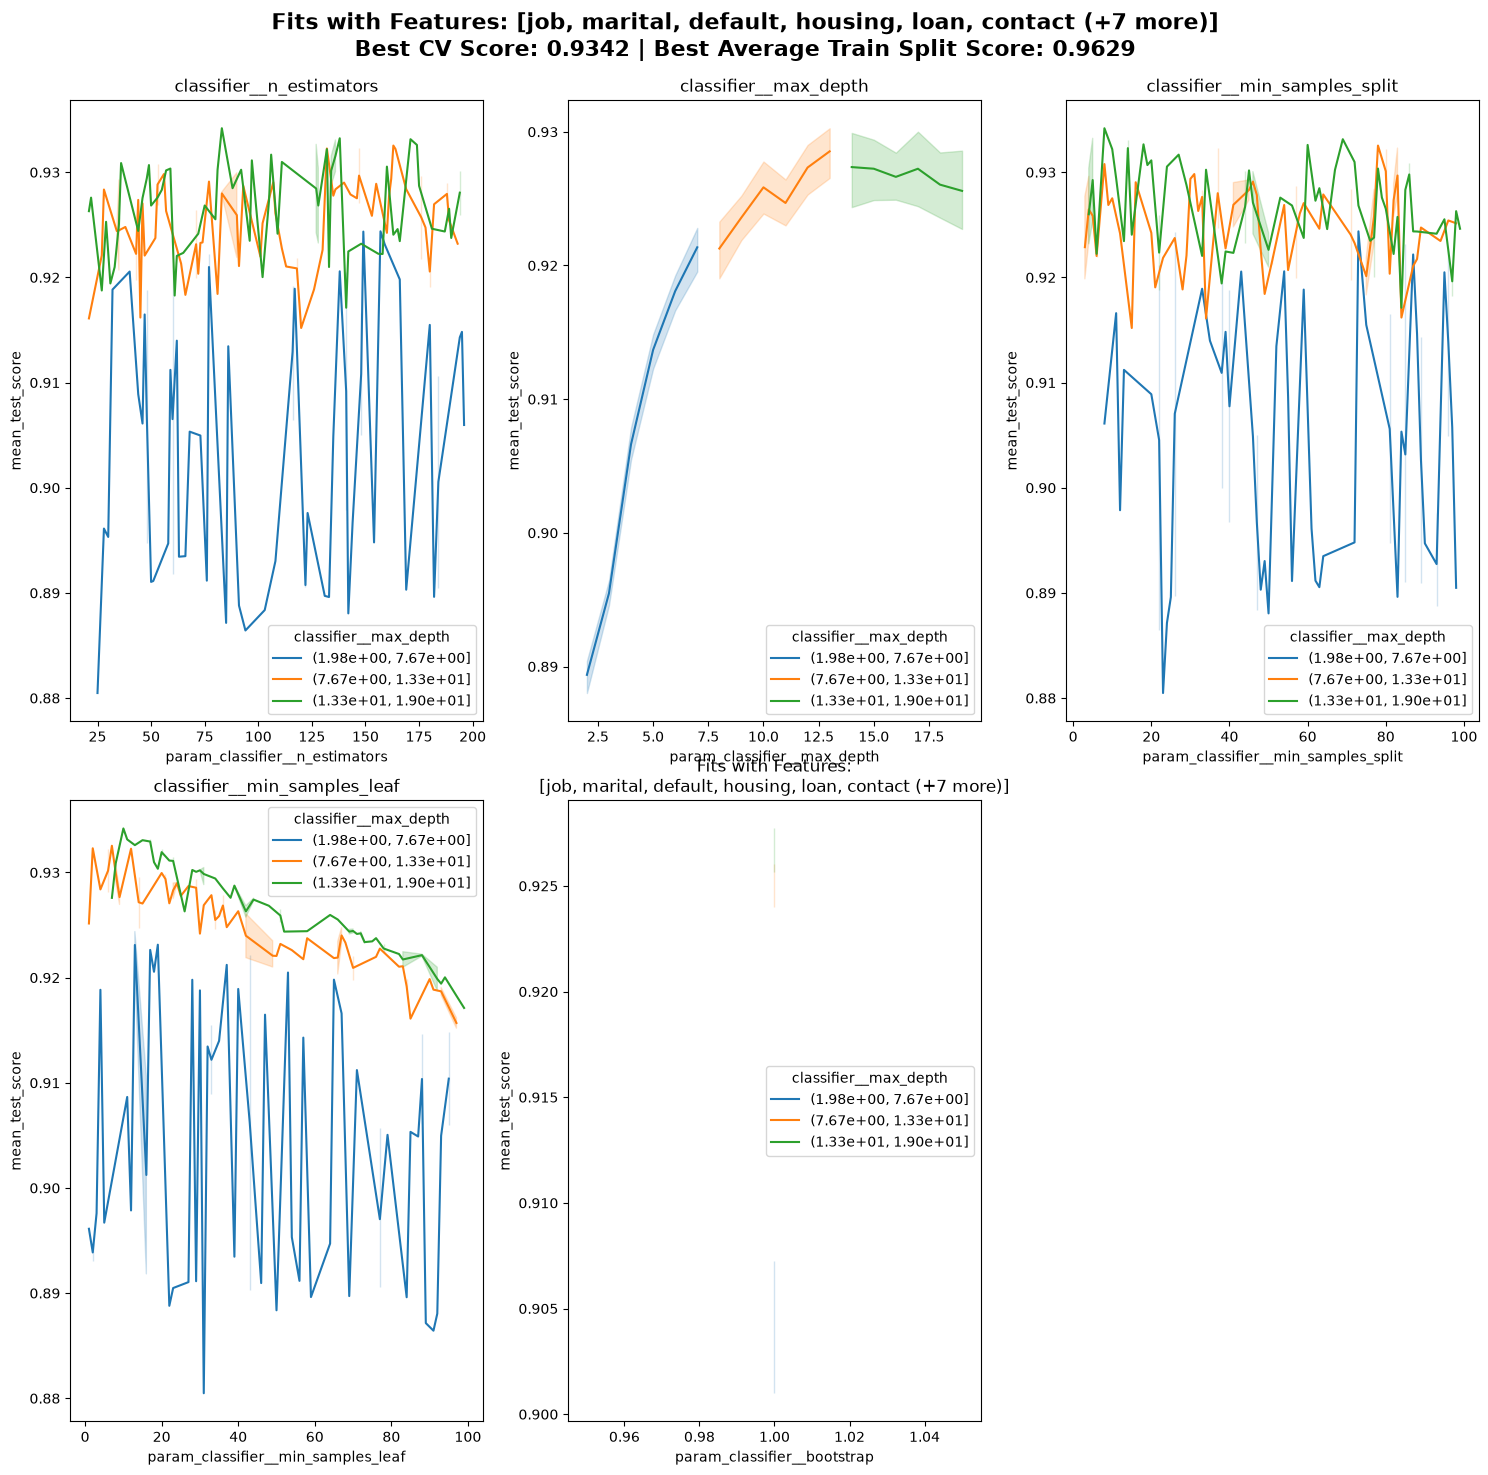

In [6]:
# Define your features
nominal_features = ['job', 'marital',  'default', 'housing', 'loan', 'contact', 'month',]

ordinal_features = ['education',]
education_order = ["primary", "secondary", "tertiary"]

numerical_features = ['age', 'balance','day', 'duration', 'campaign',]

all_features = nominal_features + ordinal_features + numerical_features



# 2. Create the transformers
numerical_transformer = Pipeline(
    steps=[
        ("Numerical", StandardScaler()),  
    ]
)
nominal_transformer = Pipeline(
    steps=[
        ("NominalEncoder", OneHotEncoder()),  
    ]
)
ordinal_transformer = Pipeline(
    steps=[
        ("OrdinalEncoder", OrdinalEncoder(categories=[education_order])), 
        ("OrdinalScaler", StandardScaler()),  
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numerical_transformer",
            numerical_transformer,
            numerical_features,
        ),
        (
            "nominal_transformer",
            nominal_transformer,
            nominal_features,
        ),
        (
            "ordinal_transformer",
            ordinal_transformer,
            ordinal_features,
        ),
    ],
    remainder="passthrough",  # Keeps any other columns untouched
)

# 4. Final Pipeline structure containing the PCA preprocessor and your classifier
pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(random_state=random_state)),
    ]
)

parameter_grid = {
    "classifier__n_estimators": randint(20, 200),
    "classifier__max_depth": randint(2,20),
    "classifier__min_samples_split": randint(1, 100),
    "classifier__min_samples_leaf": randint(1, 100),
    # "classifier__max_features": ["sqrt", "log2", None],
    # "classifier__min_weight_fraction_leaf": uniform(0.0, 0.5),
    "classifier__bootstrap": [True],
}


split1 = get_split_from_file(filename = filename, predictor='y', random_state = random_state)
t1 = PipelineTuner(pipeline, split=split1, featureNames=all_features, random_state = random_state)
search1 = t1.tune_model(hyperParameterGrid=parameter_grid, n_iter = 200, scoring = 'roc_auc')
t1.feature_permutation(search1.best_params_, scoring = 'roc_auc')
t1.shap_analysis(search1.best_params_)
t1.display_parameter_fits(search1, parameter_grid, groupby="classifier__max_depth")

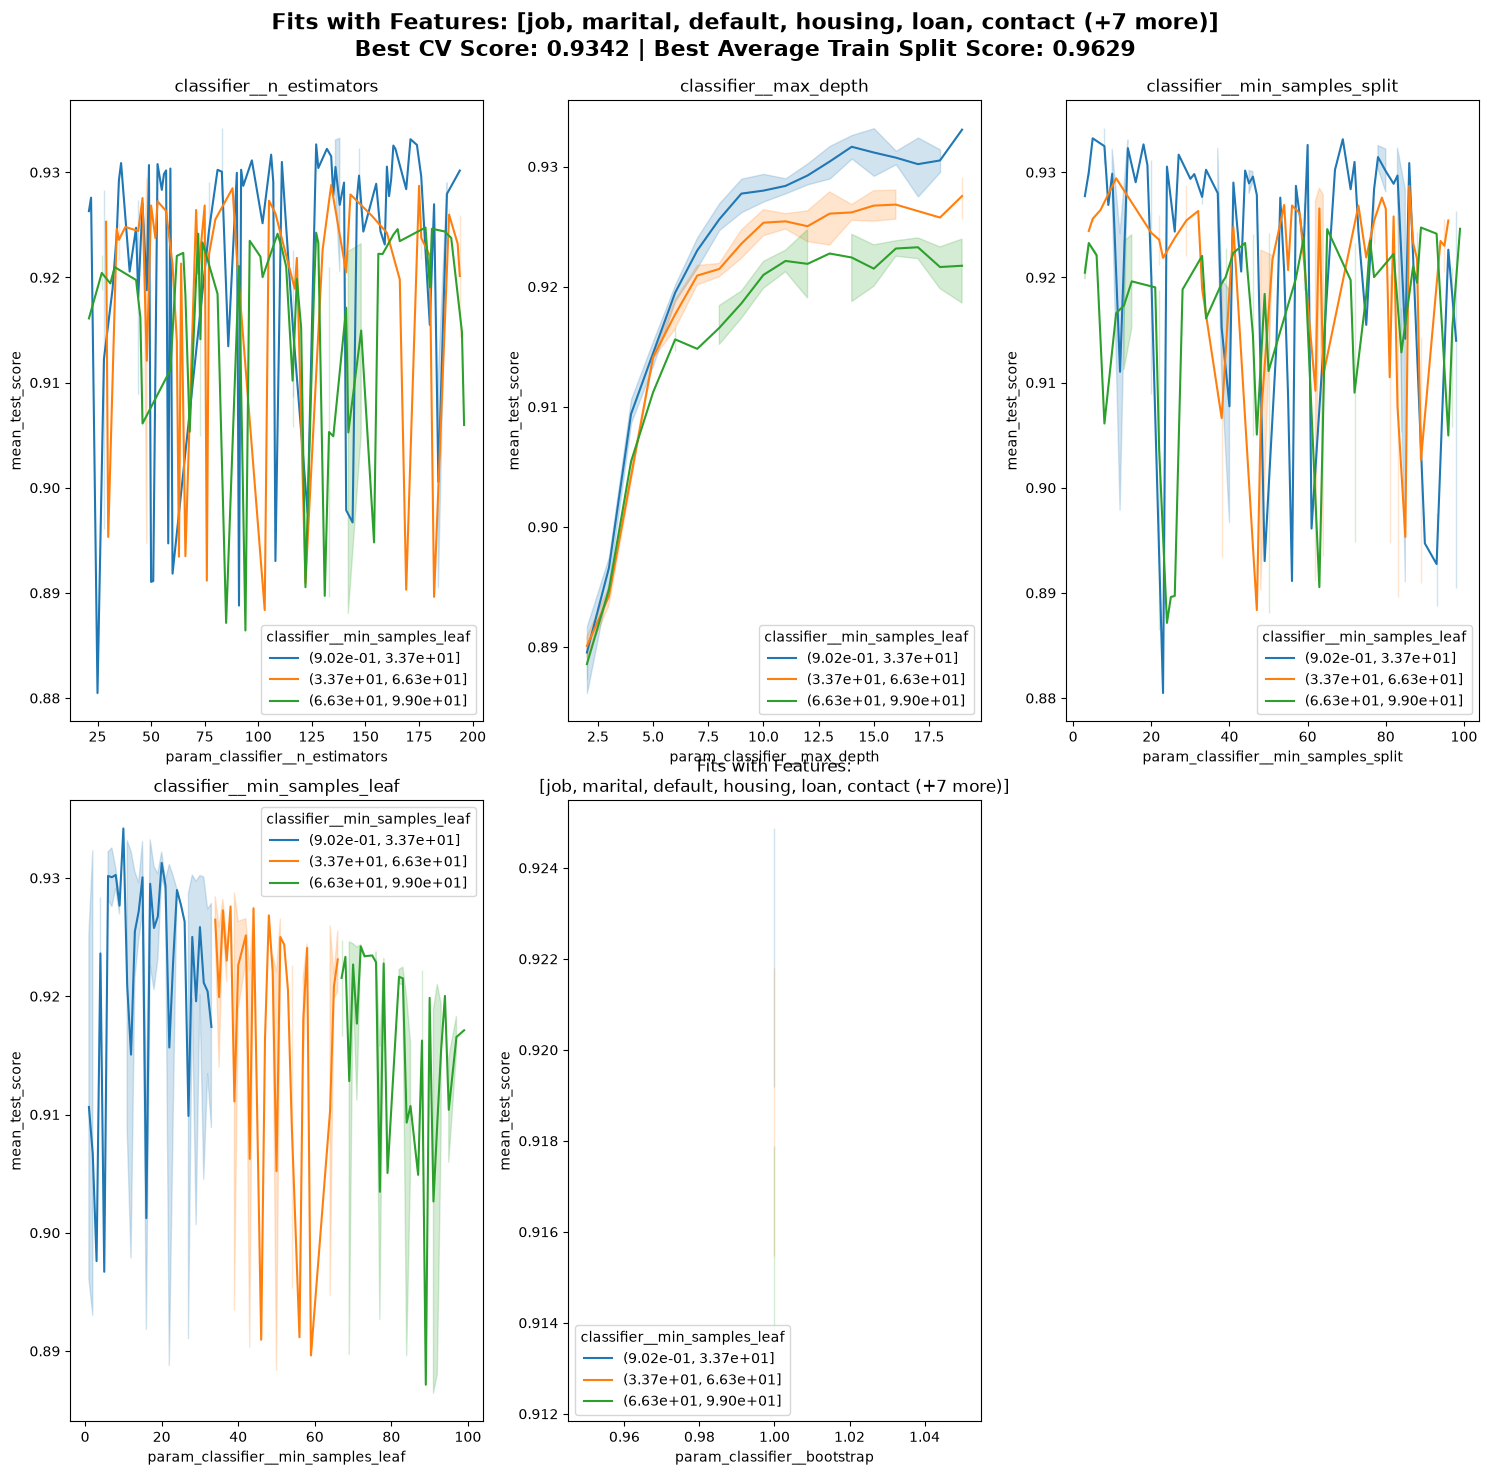

In [7]:
t1.display_parameter_fits(search1, parameter_grid, groupby="classifier__min_samples_leaf")

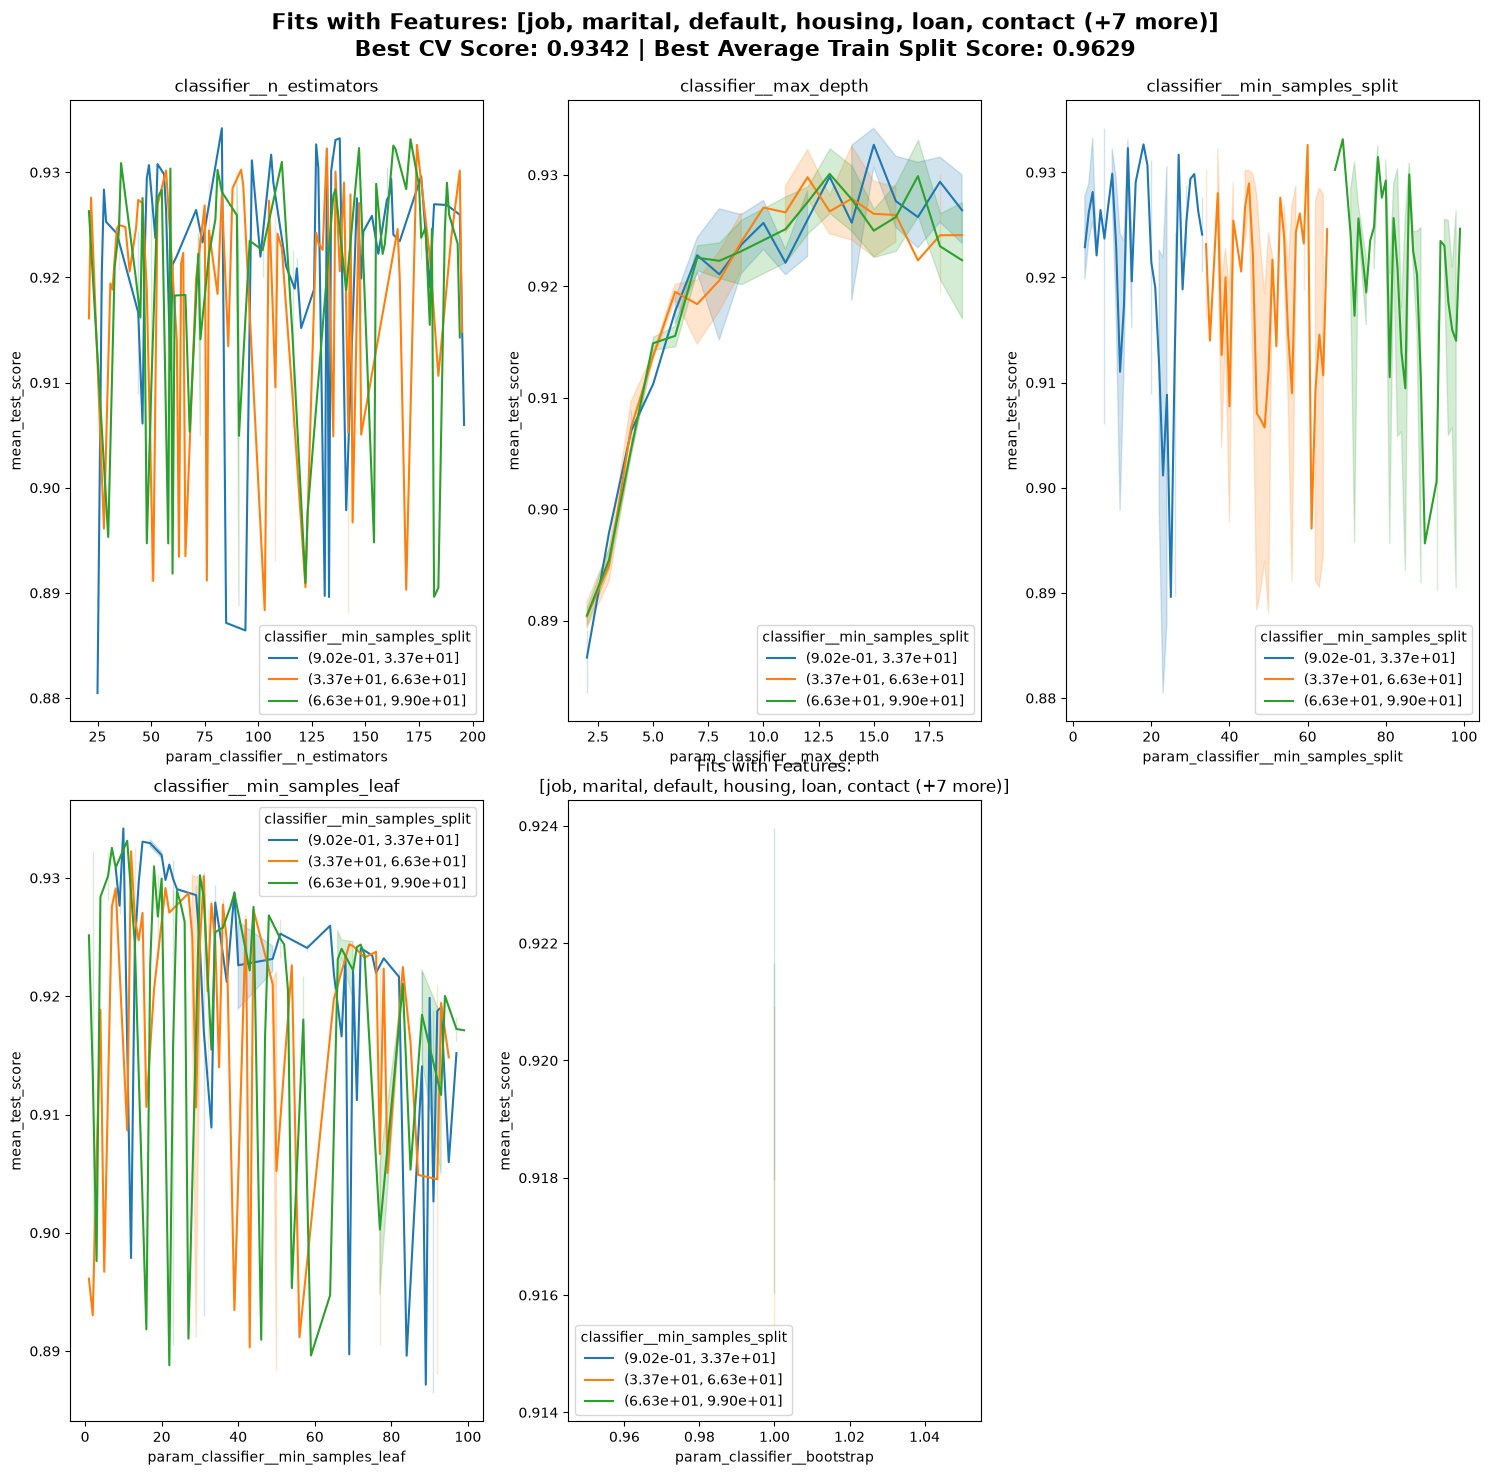

In [8]:
t1.display_parameter_fits(search1, parameter_grid, groupby="classifier__min_samples_split")


In [9]:
scores1 = t1.predict_test_split(t1.last_search.best_params_, scoring = ["roc_auc","accuracy"])
print(scores1)

{'roc_auc': 0.938124733173973, 'accuracy': 0.9207073588134627}


In [10]:
random_state += 1

Fitting 5 folds for each of 200 candidates, totalling 1000 fits
[CV 1/5; 1/200] START classifier__bootstrap=True, classifier__max_depth=10, classifier__min_samples_leaf=25, classifier__min_samples_split=82, classifier__n_estimators=42
[CV 1/5; 1/200] END classifier__bootstrap=True, classifier__max_depth=10, classifier__min_samples_leaf=25, classifier__min_samples_split=82, classifier__n_estimators=42;, score=(train=0.943, test=0.926) total time=   0.4s
[CV 2/5; 1/200] START classifier__bootstrap=True, classifier__max_depth=10, classifier__min_samples_leaf=25, classifier__min_samples_split=82, classifier__n_estimators=42
[CV 2/5; 1/200] END classifier__bootstrap=True, classifier__max_depth=10, classifier__min_samples_leaf=25, classifier__min_samples_split=82, classifier__n_estimators=42;, score=(train=0.944, test=0.910) total time=   0.4s
[CV 3/5; 1/200] START classifier__bootstrap=True, classifier__max_depth=10, classifier__min_samples_leaf=25, classifier__min_samples_split=82, classif

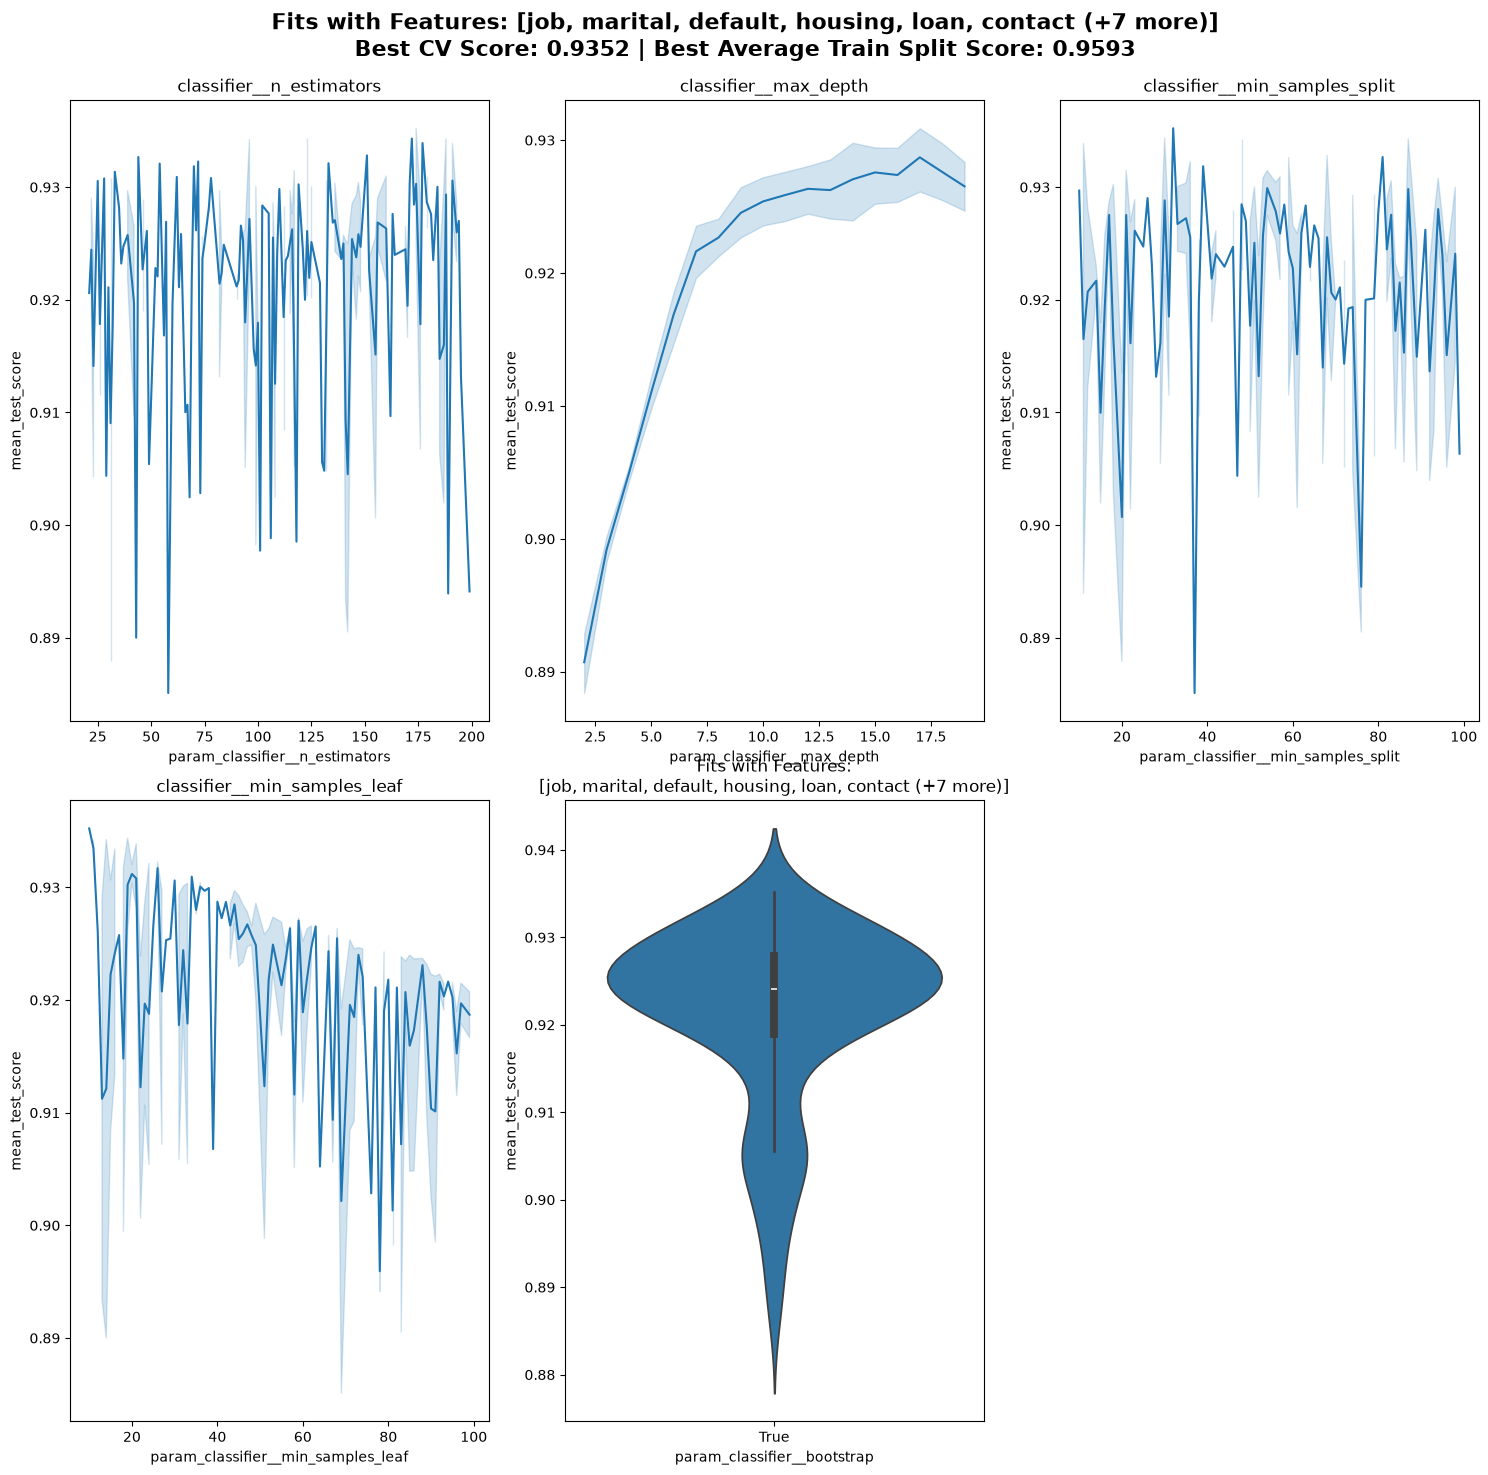



Feature Permutation Importance
______________________
duration: 0.269 +/- 0.011
month: 0.076 +/- 0.003
day: 0.014 +/- 0.001
housing: 0.012 +/- 0.001
balance: 0.003 +/- 0.001
age: 0.002 +/- 0.001
campaign: 0.001 +/- 0.001
loan: 0.000 +/- 0.001
education: 0.000 +/- 0.000
job: 0.000 +/- 0.000
contact: 0.000 +/- 0.000
default: 0.000 +/- 0.000
marital: -0.000 +/- 0.001

______________________



classifier:  RandomForestClassifier(max_depth=13, min_samples_leaf=10, min_samples_split=32,
                       n_estimators=174, random_state=2) 





e:\dev\workspace\Apziva\Project2\src\utils\tune_hyperparameters.py:433: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values.values[:, :, i], X_test_transformed_df, show=False)


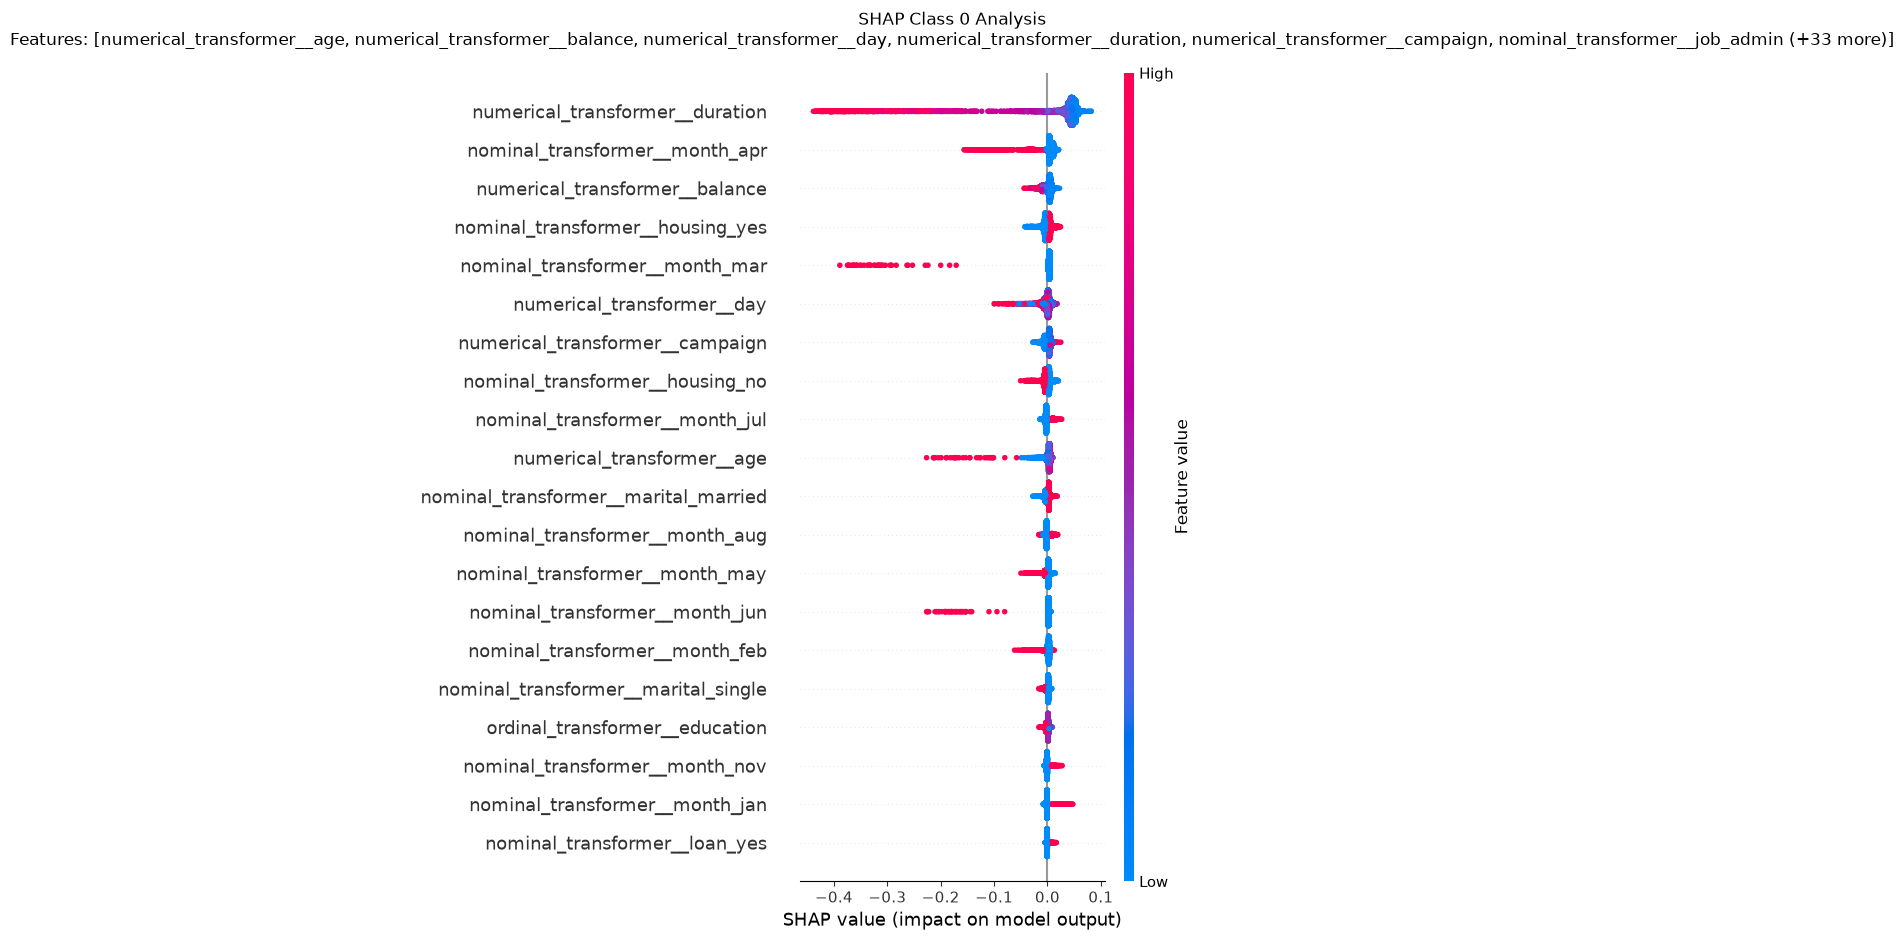

e:\dev\workspace\Apziva\Project2\src\utils\tune_hyperparameters.py:433: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values.values[:, :, i], X_test_transformed_df, show=False)


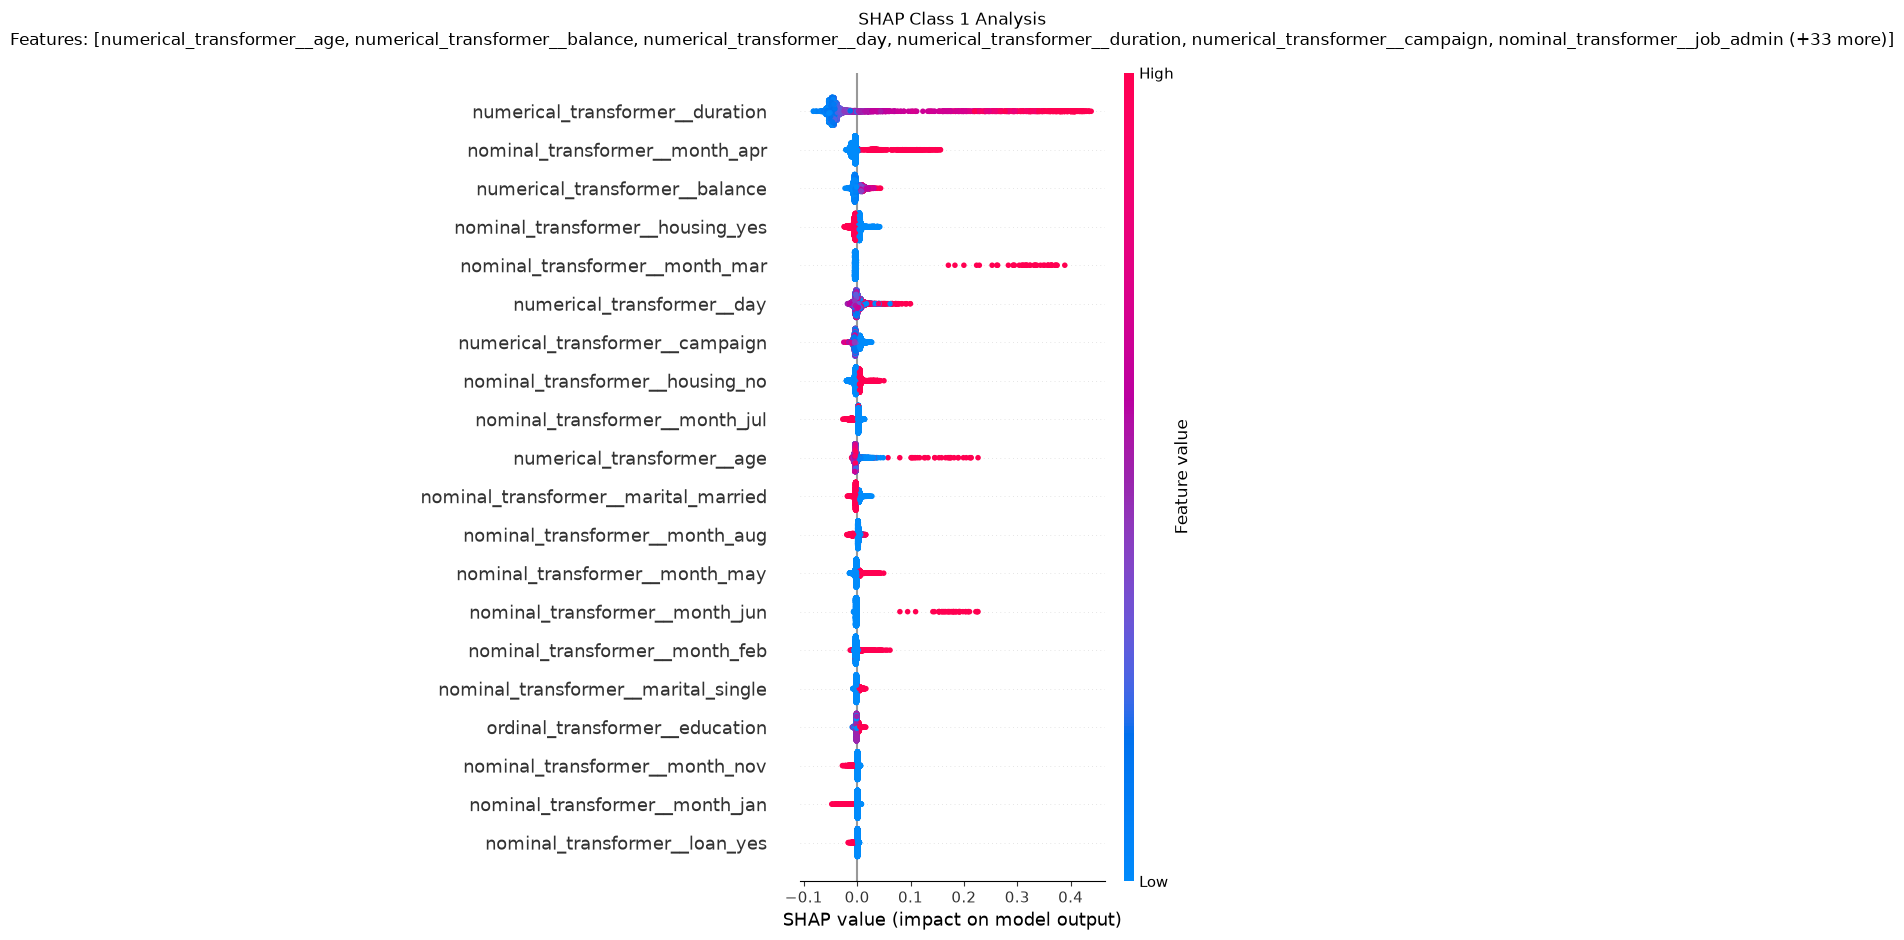

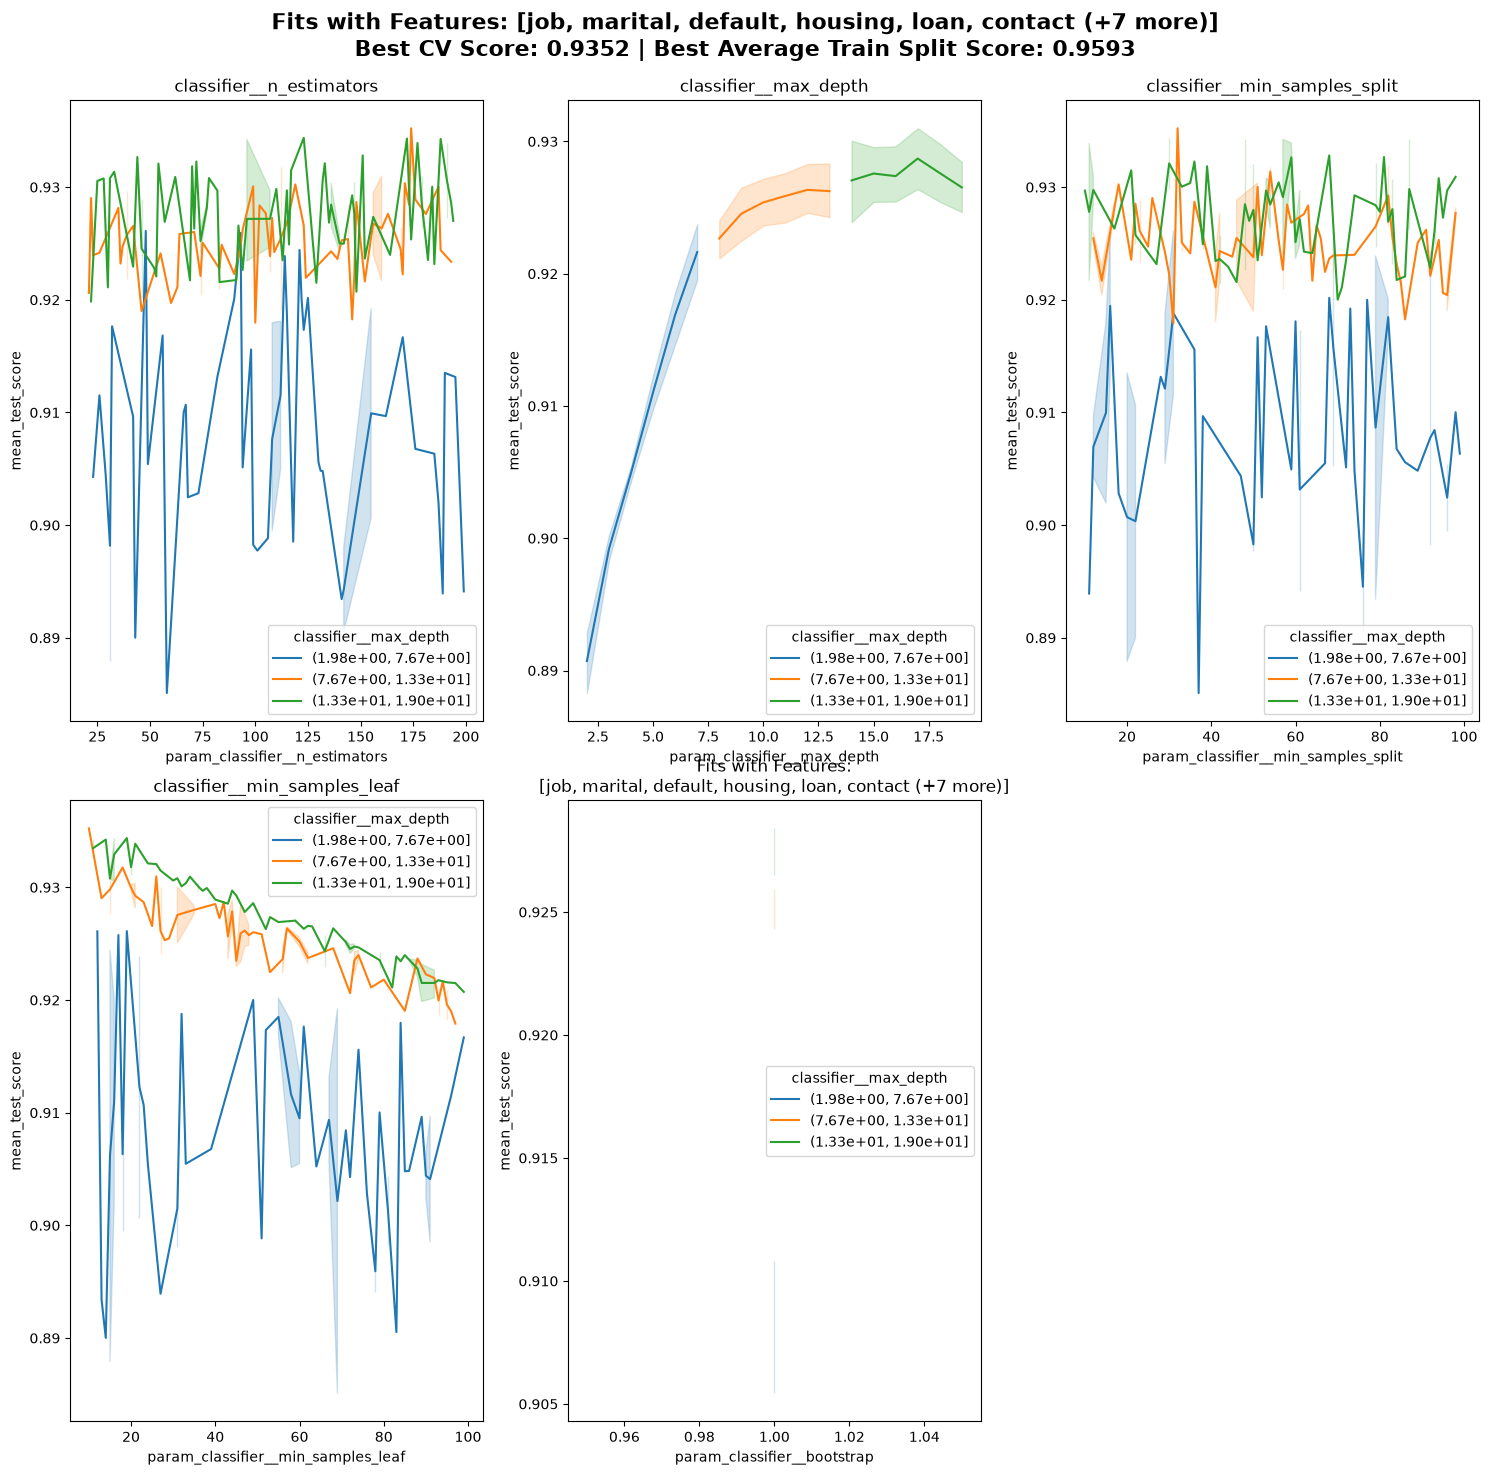

In [11]:
# Define your features
nominal_features = ['job', 'marital',  'default', 'housing', 'loan', 'contact', 'month',]

ordinal_features = ['education',]
education_order = ["primary", "secondary", "tertiary"]

numerical_features = ['age', 'balance','day', 'duration', 'campaign',]

all_features = nominal_features + ordinal_features + numerical_features



# 2. Create the transformers
numerical_transformer = Pipeline(
    steps=[
        ("Numerical", StandardScaler()),  
    ]
)
nominal_transformer = Pipeline(
    steps=[
        ("NominalEncoder", OneHotEncoder()),  
    ]
)
ordinal_transformer = Pipeline(
    steps=[
        ("OrdinalEncoder", OrdinalEncoder(categories=[education_order])), 
        ("OrdinalScaler", StandardScaler()),  
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numerical_transformer",
            numerical_transformer,
            numerical_features,
        ),
        (
            "nominal_transformer",
            nominal_transformer,
            nominal_features,
        ),
        (
            "ordinal_transformer",
            ordinal_transformer,
            ordinal_features,
        ),
    ],
    remainder="passthrough",  # Keeps any other columns untouched
)

# 4. Final Pipeline structure containing the PCA preprocessor and your classifier
pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(random_state=random_state)),
    ]
)

parameter_grid = {
    "classifier__n_estimators": randint(20, 200),
    "classifier__max_depth": randint(2,20),
    "classifier__min_samples_split": randint(10, 100),
    "classifier__min_samples_leaf": randint(10, 100),
    # "classifier__max_features": ["sqrt", "log2", None],
    # "classifier__min_weight_fraction_leaf": uniform(0.0, 0.5),
    "classifier__bootstrap": [True],
}


split2 = get_split_from_file(filename = filename, predictor='y', random_state = random_state)
t2 = PipelineTuner(pipeline, split=split2, featureNames=all_features, random_state = random_state)
search2 = t2.tune_model(hyperParameterGrid=parameter_grid, n_iter = 200, scoring = 'roc_auc')
t2.feature_permutation(search2.best_params_, scoring = 'roc_auc')
t2.shap_analysis(search2.best_params_)
t2.display_parameter_fits(search2, parameter_grid, groupby="classifier__max_depth")

In [12]:
scores2 = t2.predict_test_split(t2.last_search.best_params_, scoring = ["roc_auc","accuracy"])
print(scores2)

{'roc_auc': 0.9300118709435689, 'accuracy': 0.9180452557520441}


In [13]:
print(scores2)
print(t2.last_search.best_params_)
print(scores1)
print(t1.last_search.best_params_)
print(scores)
print(t.last_search.best_params_)

{'roc_auc': 0.9300118709435689, 'accuracy': 0.9180452557520441}
{'classifier__bootstrap': True, 'classifier__max_depth': 13, 'classifier__min_samples_leaf': 10, 'classifier__min_samples_split': 32, 'classifier__n_estimators': 174}
{'roc_auc': 0.938124733173973, 'accuracy': 0.9207073588134627}
{'classifier__bootstrap': True, 'classifier__max_depth': 15, 'classifier__min_samples_leaf': 10, 'classifier__min_samples_split': 8, 'classifier__n_estimators': 83}
{'roc_auc': 0.9324020467019852, 'accuracy': 0.9241300627495722}
{'classifier__bootstrap': True, 'classifier__max_depth': 15, 'classifier__n_estimators': 141}


In [14]:
best_model = t1.last_search.best_estimator_
best_split = split1
best_model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](2,)","['no','yes']"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](13,)","['job','marital','default',...,'day','duration','campaign']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,13
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numerical_transformer', ...), ('nominal_transformer', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By spec

# Tuning the best ROC_AUC model

In [15]:
from src.utils.tune_thresholds import ClassificationThresholdTuner
import joblib

In [16]:
tuner = ClassificationThresholdTuner(model_estimator=best_model, split=best_split,)

Scoring: roc_auc, Best Threshold: 0.08899541531904133, Training Score: 0.8698470487162514
Scoring: f1, Best Threshold: 0.2629578241761615, Training Score: 0.6067415730337079



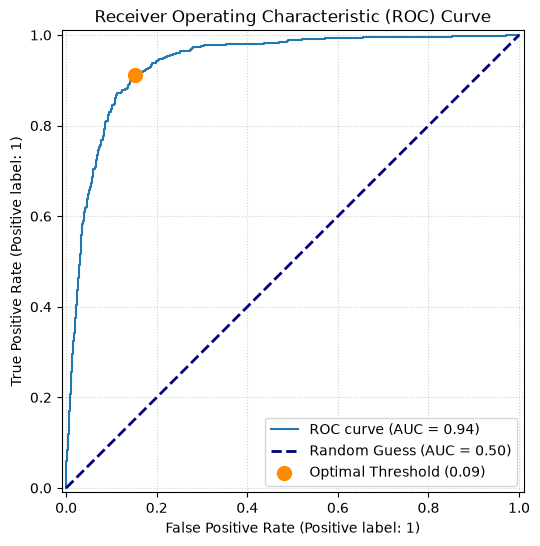

e:\dev\workspace\Apziva\Project2\.venv\Lib\site-packages\sklearn\utils\_plotting.py:193: FutureWarning: `**kwargs` is deprecated and will be removed in 1.11. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


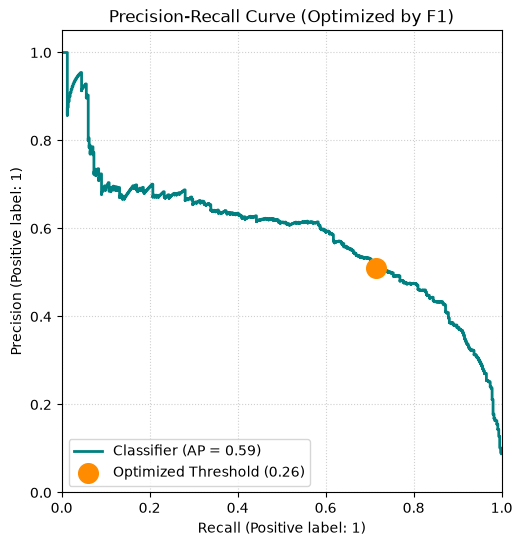

e:\dev\workspace\Apziva\Project2\.venv\Lib\site-packages\sklearn\utils\_plotting.py:193: FutureWarning: `**kwargs` is deprecated and will be removed in 1.11. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


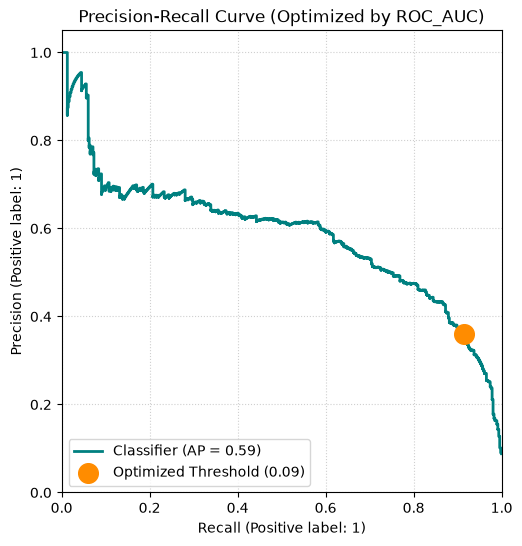

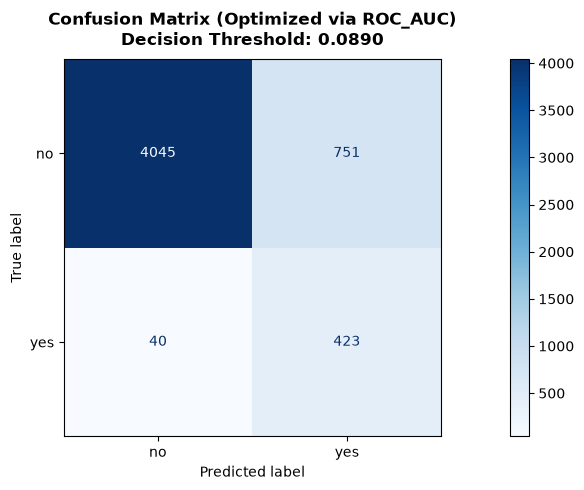

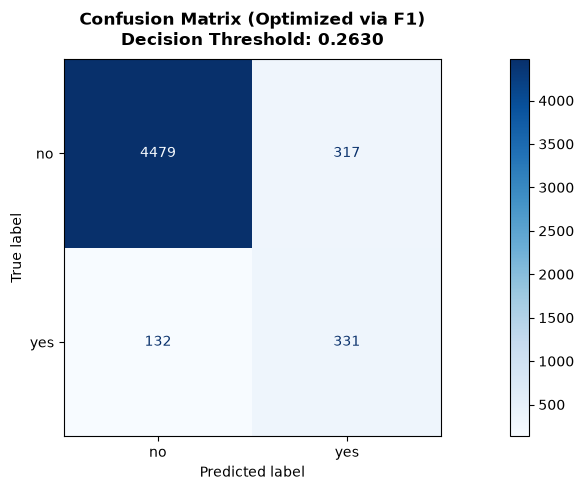


 CLASSIFICATION REPORT FOR MODEL OPTIMIZED BY: [ROC_AUC]
 Optimized Threshold Boundary: 0.0890
              precision    recall  f1-score   support

          no       0.99      0.84      0.91      4796
         yes       0.36      0.91      0.52       463

    accuracy                           0.85      5259
   macro avg       0.68      0.88      0.71      5259
weighted avg       0.93      0.85      0.88      5259


 CLASSIFICATION REPORT FOR MODEL OPTIMIZED BY: [F1]
 Optimized Threshold Boundary: 0.2630
              precision    recall  f1-score   support

          no       0.97      0.93      0.95      4796
         yes       0.51      0.71      0.60       463

    accuracy                           0.91      5259
   macro avg       0.74      0.82      0.77      5259
weighted avg       0.93      0.91      0.92      5259

Successfully serialized pipeline to: ../../src/models/saved_models/ThresholdTunedRandomForestClassifier_max_sales.joblib
Successfully serialized pipeline to: .

In [17]:
print(tuner)
tuner.get_roc_curve()
tuner.get_precision_recall_curve()
tuner.get_precision_recall_curve("roc_auc")
tuner.get_confusion_matrix()
tuner.print_classification_reports()
tuner.save_model(metric_key="roc_auc", filepath_prefix="ThresholdTunedRandomForestClassifier_max_sales")
tuner.save_model(metric_key="f1", filepath_prefix="ThresholdTunedRandomForestClassifier_efficient")

In [18]:
# untuned-model
from sklearn.metrics import classification_report
X_train, X_test, y_train, y_test = split
best_model.fit(X_train, y_train)
y_preds = best_model.predict(X_test)
print(classification_report(y_test, y_preds))

              precision    recall  f1-score   support

          no       0.93      0.99      0.96      4796
         yes       0.71      0.20      0.31       463

    accuracy                           0.92      5259
   macro avg       0.82      0.60      0.64      5259
weighted avg       0.91      0.92      0.90      5259

